# Анализ Turbovec для детекции аномалий

Пайплайн анализа:
1. Загрузка результатов бенчмарка (baseline и turbovec bw=2/bw=4, для k=5 и k=10)
2. Объединение всех прогонов в две таблицы — **raw** и **normalized** с общими колонками `variant`, `bit_width`, `k`
3. Персентили времени поиска (`time_ms`) по вариантам
4. Сравнение времени: t-test baseline vs turbovec
5. Метрики качества детекции (ROC-AUC / PR-AUC) и статистическая проверка разницы
6. Анализ во времени: посмотреть, растёт ли частота ошибок ближе к концу теста (сортировка по `test_id`)

In [3]:
# Утилиты
from pathlib import Path
RESULTS_DIR = str(Path.cwd().parent / "results/anomaly_detection")
RESULTS_DIR = RESULTS_DIR.replace('\\', '/') + '/'

In [90]:
# Библиотеки для анализа данных
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score

## 1. Загрузка данных выборочно


In [5]:
bl_norm_k5 = pd.read_csv(RESULTS_DIR + 'baseline_normalized_k5_20260702_193041.csv')
tv_norm_bw2_k5 = pd.read_csv(RESULTS_DIR + 'turbovec_normalized_bw2_k5_20260702_193041.csv')

In [6]:
bl_norm_k5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84807 entries, 0 to 84806
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   test_id        84807 non-null  int64  
 1   true_label     84807 non-null  int64  
 2   anomaly_score  84807 non-null  float64
 3   time_ms        84807 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 2.6 MB


In [7]:
tv_norm_bw2_k5.head()

,test_id,true_label,anomaly_score,time_ms
0,1,0,0.068033,118.789196
1,2,0,0.056097,3.662348
2,3,0,0.048913,1.395464
3,4,0,0.005556,3.006697
4,5,0,0.062099,3.893614


In [19]:
share = bl_norm_k5.groupby('true_label')['test_id'].count().reset_index()
share

,true_label,test_id
0,0,84700
1,1,107


## 2. Группировка таблиц

In [12]:
RUN_ID = {5: '20260702_193041', 10: '20260702_195413'}

file_specs = []
for k, ts in RUN_ID.items():
    file_specs.append(dict(method='baseline', bit_width=np.nan, k=k, form='normalized',
                            path=f'baseline_normalized_k{k}_{ts}.csv'))
    file_specs.append(dict(method='baseline', bit_width=np.nan, k=k, form='raw',
                            path=f'baseline_raw_k{k}_{ts}.csv'))
    for bw in [2, 4]:
        file_specs.append(dict(method='turbovec', bit_width=bw, k=k, form='normalized',
                                path=f'turbovec_normalized_bw{bw}_k{k}_{ts}.csv'))
        file_specs.append(dict(method='turbovec', bit_width=bw, k=k, form='raw',
                                path=f'turbovec_raw_bw{bw}_k{k}_{ts}.csv'))

frames = []
for spec in file_specs:
    df = pd.read_csv(RESULTS_DIR + spec['path'])
    df['method'] = spec['method']
    df['bit_width'] = spec['bit_width']
    df['k'] = spec['k']
    df['form'] = spec['form']
    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)

def make_variant(row):
    if row['method'] == 'baseline':
        return 'baseline'
    return f"turbovec_bw{int(row['bit_width'])}"

all_df['variant'] = all_df.apply(make_variant, axis=1)

df_norm = all_df[all_df['form'] == 'normalized'].drop(columns='form').reset_index(drop=True)
df_raw = all_df[all_df['form'] == 'raw'].drop(columns='form').reset_index(drop=True)

print('df_raw:', df_raw.shape, '| df_norm:', df_norm.shape)
df_raw.head()

df_raw: (508842, 8) | df_norm: (508842, 8)


,test_id,true_label,anomaly_score,time_ms,method,bit_width,k,variant
0,1,0,-142.112340,3.782034,baseline,NaN,5,baseline
1,2,0,-86.787224,2.913952,baseline,NaN,5,baseline
2,3,0,-131.642790,2.629995,baseline,NaN,5,baseline
3,4,0,-26.201986,2.393723,baseline,NaN,5,baseline
4,5,0,-137.563570,4.158258,baseline,NaN,5,baseline


In [13]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508842 entries, 0 to 508841
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   test_id        508842 non-null  int64  
 1   true_label     508842 non-null  int64  
 2   anomaly_score  508842 non-null  float64
 3   time_ms        508842 non-null  float64
 4   method         508842 non-null  object 
 5   bit_width      339228 non-null  float64
 6   k              508842 non-null  int64  
 7   variant        508842 non-null  object 
dtypes: float64(3), int64(3), object(2)
memory usage: 31.1+ MB


In [15]:
all_df.head()

,test_id,true_label,anomaly_score,time_ms,method,bit_width,k,form,variant
0,1,0,0.079222,5.066872,baseline,NaN,5,normalized,baseline
1,2,0,0.067135,5.532742,baseline,NaN,5,normalized,baseline
2,3,0,0.078340,6.248713,baseline,NaN,5,normalized,baseline
3,4,0,0.019502,4.857779,baseline,NaN,5,normalized,baseline
4,5,0,0.102457,5.443335,baseline,NaN,5,normalized,baseline


## 3. Персентили времени поиска

Цикл по всем комбинациям `variant` х `k`, считает персентили `time_ms`

In [21]:
PERCENTILES = [25, 50, 75, 90, 95, 99]

def compute_percentiles(df, value_col='time_ms', group_cols=('variant', 'k')):
    rows = []
    for keys, g in df.groupby(list(group_cols)):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row['n'] = len(g)
        for p in PERCENTILES:
            row[f'p{p}'] = np.percentile(g[value_col], p)
        rows.append(row)
    return pd.DataFrame(rows).sort_values(list(group_cols)).reset_index(drop=True)

In [22]:
time_percentiles_raw = compute_percentiles(df_raw)
time_percentiles_raw

,variant,k,n,p25,p50,p75,p90,p95,p99
0,baseline,5,84807,2.024889,2.125502,2.576351,3.992319,4.684138,5.402327
1,baseline,10,84807,2.066851,3.328562,4.279256,4.963875,5.180764,5.806208
2,turbovec_bw2,5,84807,0.495195,0.517130,0.852108,0.937700,0.975847,1.329799
3,turbovec_bw2,10,84807,0.496387,0.536919,0.898123,0.989676,1.303363,1.970472
4,turbovec_bw4,5,84807,0.768304,1.296282,1.510859,2.508402,2.598286,3.381910
5,turbovec_bw4,10,84807,0.777006,1.059771,1.512051,2.489090,2.608538,3.244033


In [23]:

time_percentiles_norm = compute_percentiles(df_norm)
time_percentiles_norm

,variant,k,n,p25,p50,p75,p90,p95,p99
0,baseline,5,84807,3.658056,3.993034,4.707813,5.075932,5.306721,6.334529
1,baseline,10,84807,2.264500,3.767729,4.562855,5.079985,5.385399,6.511407
2,turbovec_bw2,5,84807,0.957251,1.397848,1.676798,1.773596,1.905918,3.256416
3,turbovec_bw2,10,84807,0.519276,0.751257,1.003981,1.630306,1.752615,2.424941
4,turbovec_bw4,5,84807,0.759840,0.839710,1.279354,1.437664,1.560926,2.537251
5,turbovec_bw4,10,84807,0.810862,1.382828,1.896620,2.558327,2.718687,4.501143


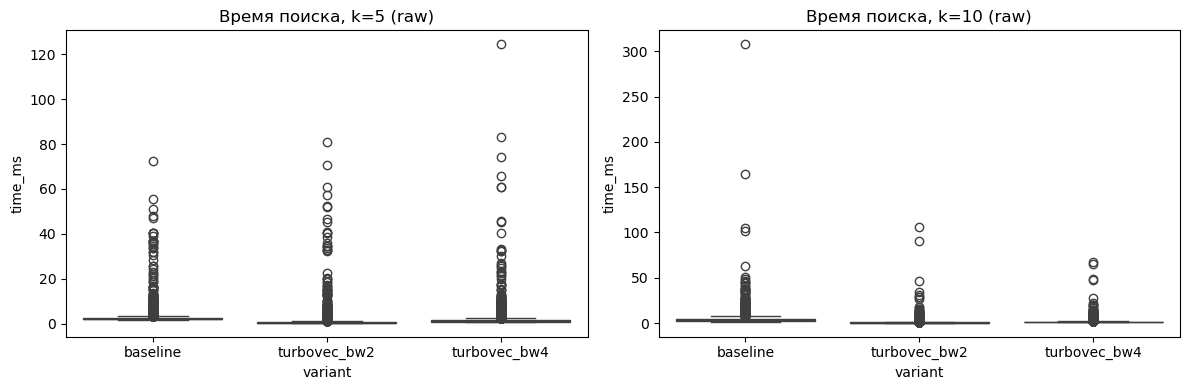

In [37]:
fig, axes = plt.subplots(1, len(RUN_ID), figsize=(6 * len(RUN_ID), 4), sharey=False)
for ax, k in zip(np.atleast_1d(axes), RUN_ID):
    sub = df_raw[df_raw['k'] == k]
    sns.boxplot(data=sub, x='variant', y='time_ms', ax=ax)
    ax.set_title(f'Время поиска, k={k} (raw)')
plt.tight_layout()
plt.show()

## 4. t-test: время baseline vs turbovec (bw=2, bw=4)

Считаем тесты:
- **Welch t-test** (`ttest_ind`, `equal_var=False`) - t-test для сравнения времени двух групп
- **Парный t-test** (`ttest_rel`)

In [24]:
def compare_time_ttest(df, k):
    sub = df[df['k'] == k]
    baseline = sub[sub['variant'] == 'baseline'][['test_id', 'time_ms']].rename(
        columns={'time_ms': 'time_baseline'})
    results = []
    for bw in [2, 4]:
        variant_name = f'turbovec_bw{bw}'
        tv = sub[sub['variant'] == variant_name][['test_id', 'time_ms']].rename(
            columns={'time_ms': 'time_turbovec'})
        paired = baseline.merge(tv, on='test_id', how='inner')

        t_ind, p_ind = stats.ttest_ind(paired['time_baseline'], paired['time_turbovec'], equal_var=False)
        t_rel, p_rel = stats.ttest_rel(paired['time_baseline'], paired['time_turbovec'])

        results.append({
            'k': k, 'bit_width': bw, 'n_paired': len(paired),
            'mean_baseline_ms': paired['time_baseline'].mean(),
            'mean_turbovec_ms': paired['time_turbovec'].mean(),
            'welch_t_stat': t_ind, 'welch_p_value': p_ind,
            'paired_t_stat': t_rel, 'paired_p_value': p_rel,
        })
    return pd.DataFrame(results)

In [25]:
ttest_time_raw = pd.concat([compare_time_ttest(df_raw, k) for k in RUN_ID], ignore_index=True)
ttest_time_raw

,k,bit_width,n_paired,mean_baseline_ms,mean_turbovec_ms,welch_t_stat,welch_p_value,paired_t_stat,paired_p_value
0,5,2,84807,2.544577,0.665625,395.744971,0.0,395.862910,0.0
1,5,4,84807,2.544577,1.370977,219.406753,0.0,234.741973,0.0
2,10,2,84807,3.293731,0.722640,367.849768,0.0,362.076356,0.0
3,10,4,84807,3.293731,1.314064,275.960679,0.0,290.009807,0.0


In [26]:
ttest_time_norm = pd.concat([compare_time_ttest(df_norm, k) for k in RUN_ID], ignore_index=True)
ttest_time_norm

,k,bit_width,n_paired,mean_baseline_ms,mean_turbovec_ms,welch_t_stat,welch_p_value,paired_t_stat,paired_p_value
0,5,2,84807,4.226987,1.400751,496.821913,0.0,496.092262,0.0
1,5,4,84807,4.226987,1.045056,503.881692,0.0,505.835477,0.0
2,10,2,84807,3.643985,0.901500,367.988770,0.0,381.538884,0.0
3,10,4,84807,3.643985,1.529188,259.764671,0.0,245.776591,0.0


### Turbovec обрабатывает запросы быстрее, есть статистически значимая разница

## 5. Метрики точности детекции (ROC-AUC / PR-AUC)

Стандартный вариант для anomaly detection:
- **ROC-AUC** - общая способность разделять классы
- **PR-AUC (average precision)** - устойчивее к сильному дисбалансу классов
  (аномалий обычно <1%), важнее для анализа

In [27]:
def compute_detection_metrics(df, group_cols=('variant', 'k')):
    rows = []
    for keys, g in df.groupby(list(group_cols)):
        if not isinstance(keys, tuple):
            keys = (keys,)
        y = g['true_label'].values
        s = g['anomaly_score'].values
        row = dict(zip(group_cols, keys))
        row['n'] = len(g)
        row['n_anomalies'] = int(y.sum())
        if len(np.unique(y)) < 2:
            row['roc_auc'] = np.nan
            row['pr_auc'] = np.nan
            row['score_direction'] = None
        else:
            auc_pos = roc_auc_score(y, s)
            auc_neg = roc_auc_score(y, -s)
            if auc_pos >= auc_neg:
                row['roc_auc'] = auc_pos
                row['pr_auc'] = average_precision_score(y, s)
                row['score_direction'] = 'выше = аномальнее'
            else:
                row['roc_auc'] = auc_neg
                row['pr_auc'] = average_precision_score(y, -s)
                row['score_direction'] = 'ниже = аномальнее'
        rows.append(row)
    return pd.DataFrame(rows).sort_values(list(group_cols)).reset_index(drop=True)

In [28]:
detection_metrics_raw = compute_detection_metrics(df_raw)
detection_metrics_raw

,variant,k,n,n_anomalies,roc_auc,pr_auc,score_direction
0,baseline,5,84807,107,0.929577,0.018032,ниже = аномальнее
1,baseline,10,84807,107,0.934603,0.022147,ниже = аномальнее
2,turbovec_bw2,5,84807,107,0.926204,0.018017,ниже = аномальнее
3,turbovec_bw2,10,84807,107,0.931823,0.022500,ниже = аномальнее
4,turbovec_bw4,5,84807,107,0.929739,0.018358,ниже = аномальнее
5,turbovec_bw4,10,84807,107,0.934615,0.022442,ниже = аномальнее


In [29]:

detection_metrics_norm = compute_detection_metrics(df_norm)
detection_metrics_norm

,variant,k,n,n_anomalies,roc_auc,pr_auc,score_direction
0,baseline,5,84807,107,0.779030,0.010390,выше = аномальнее
1,baseline,10,84807,107,0.761816,0.007890,выше = аномальнее
2,turbovec_bw2,5,84807,107,0.752622,0.004276,выше = аномальнее
3,turbovec_bw2,10,84807,107,0.746115,0.004059,выше = аномальнее
4,turbovec_bw4,5,84807,107,0.781979,0.008863,выше = аномальнее
5,turbovec_bw4,10,84807,107,0.765125,0.007769,выше = аномальнее


### Проверяем разницу через Bootstrap (т.к. сравниваем не средние значения)

In [40]:
def bootstrap_ci(sample, theta_func, alpha=0.05, B=1000, random_state=None, return_samples=False):
    if random_state is not None:
        np.random.seed(random_state)

    N = len(sample)
    theta_estim = theta_func(sample)

    theta_asterisk_array = []
    for _ in range(B):
        bootstrap_sample = np.random.choice(sample, replace=True, size=N)
        theta_asterisk = theta_func(bootstrap_sample)
        theta_asterisk_array.append(theta_asterisk)
    theta_asterisk_array = np.array(theta_asterisk_array)

    left_theta_asterisk, right_theta_asterisk = np.quantile(theta_asterisk_array, [alpha / 2, 1 - alpha / 2])
    left_bound = 2 * theta_estim - right_theta_asterisk
    right_bound = 2 * theta_estim - left_theta_asterisk

    if return_samples:
        return left_bound, right_bound, theta_estim, theta_asterisk_array
    return left_bound, right_bound


def compute_auc_diff_bootstrap(df, k, bit_width, metric='roc_auc', alpha=0.05, B=1000, random_state=42):
    sub = df[df['k'] == k]
    baseline = sub[sub['variant'] == 'baseline'][['test_id', 'true_label', 'anomaly_score']]
    tv = sub[sub['variant'] == f'turbovec_bw{bit_width}'][['test_id', 'true_label', 'anomaly_score']]
    paired = baseline.merge(tv, on='test_id', suffixes=('_baseline', '_turbovec'))

    y = paired['true_label_baseline'].values
    s_baseline = paired['anomaly_score_baseline'].values
    s_turbovec = paired['anomaly_score_turbovec'].values
    metric_fn = roc_auc_score if metric == 'roc_auc' else average_precision_score

    def theta_func(idx):
        idx = np.asarray(idx)
        yy = y[idx]
        if len(np.unique(yy)) < 2:
            return np.nan
        return metric_fn(yy, s_turbovec[idx]) - metric_fn(yy, s_baseline[idx])

    sample = np.arange(len(paired))
    ci_low, ci_high, theta_hat, theta_star = bootstrap_ci(
        sample, theta_func, alpha=alpha, B=B, random_state=random_state, return_samples=True
    )

    theta_star_clean = theta_star[~np.isnan(theta_star)]
    if len(theta_star_clean):
        p_emp = min(2 * min((theta_star_clean > 0).mean(), (theta_star_clean < 0).mean()), 1.0)
    else:
        p_emp = np.nan

    return dict(k=k, bit_width=bit_width, metric=metric, n=len(paired), n_boot=len(theta_star_clean),
                observed_diff_turbovec_minus_baseline=theta_hat,
                ci95_low=ci_low, ci95_high=ci_high, p_value_empirical=p_emp)

In [41]:
boot_rows_raw = []
for k in RUN_ID:
    for bw in [2, 4]:
        for metric in ['roc_auc', 'pr_auc']:
            boot_rows_raw.append(compute_auc_diff_bootstrap(df_raw, k, bw, metric=metric))

In [42]:
accuracy_significance_raw = pd.DataFrame(boot_rows_raw)
accuracy_significance_raw

,k,bit_width,metric,n,n_boot,observed_diff_turbovec_minus_baseline,ci95_low,ci95_high,p_value_empirical
0,5,2,roc_auc,84807,1000,3.372706e-03,5.144744e-04,5.579802e-03,0.004
1,5,2,pr_auc,84807,1000,6.154868e-07,-8.761280e-07,1.189440e-06,0.028
2,5,4,roc_auc,84807,1000,-1.618135e-04,-7.468264e-04,2.848311e-04,0.512
3,5,4,pr_auc,84807,1000,-1.868742e-07,-3.941051e-07,-5.838657e-08,0.062
4,10,2,roc_auc,84807,1000,2.779684e-03,5.055452e-04,4.671972e-03,0.002
5,10,2,pr_auc,84807,1000,3.518358e-07,-9.054487e-07,8.321199e-07,0.198
6,10,4,roc_auc,84807,1000,-1.202706e-05,-4.820643e-04,3.895908e-04,0.936
7,10,4,pr_auc,84807,1000,-1.050873e-07,-2.689912e-07,-1.036091e-08,0.160


In [43]:
boot_rows_norm = []
for k in RUN_ID:
    for bw in [2, 4]:
        for metric in ['roc_auc', 'pr_auc']:
            boot_rows_norm.append(compute_auc_diff_bootstrap(df_norm, k, bw, metric=metric))

In [44]:
accuracy_significance_norm = pd.DataFrame(boot_rows_norm)
accuracy_significance_norm

,k,bit_width,metric,n,n_boot,observed_diff_turbovec_minus_baseline,ci95_low,ci95_high,p_value_empirical
0,5,2,roc_auc,84807,1000,-0.026408,-0.039248,-0.010544,0.000
1,5,2,pr_auc,84807,1000,-0.006114,-0.011189,0.012704,0.000
2,5,4,roc_auc,84807,1000,0.002949,-0.001178,0.007438,0.246
3,5,4,pr_auc,84807,1000,-0.001527,-0.003928,0.008473,0.654
4,10,2,roc_auc,84807,1000,-0.015701,-0.026501,-0.002245,0.002
5,10,2,pr_auc,84807,1000,-0.003832,-0.007001,0.008878,0.000
6,10,4,roc_auc,84807,1000,0.003308,-0.000527,0.007260,0.112
7,10,4,pr_auc,84807,1000,-0.000121,-0.001448,0.004470,0.940


In [48]:
def bootstrap_ci_multi(sample, theta_funcs, alpha=0.05, B=2000, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    N = len(sample)

    theta_hat = {name: f(sample) for name, f in theta_funcs.items()}
    theta_star = {name: np.empty(B) for name in theta_funcs}

    for b in range(B):
        idx = np.random.choice(sample, replace=True, size=N)
        for name, f in theta_funcs.items():
            theta_star[name][b] = f(idx)

    result = {}
    for name in theta_funcs:
        arr = theta_star[name][~np.isnan(theta_star[name])]
        if len(arr) == 0:
            result[name] = dict(theta_hat=theta_hat[name], ci_low=np.nan, ci_high=np.nan)
            continue
        left_q, right_q = np.quantile(arr, [alpha / 2, 1 - alpha / 2])
        result[name] = dict(
            theta_hat=theta_hat[name],
            ci_low=2 * theta_hat[name] - right_q,
            ci_high=2 * theta_hat[name] - left_q,
        )
    return result

In [49]:
def build_ci_table(df, metric='roc_auc', B=2000, random_state=42):
    metric_fn = roc_auc_score if metric == 'roc_auc' else average_precision_score
    rows = []
    for k in RUN_ID:
        sub = df[df['k'] == k]
        baseline = sub[sub['variant'] == 'baseline'][['test_id', 'true_label', 'anomaly_score']]
        for bw in [2, 4]:
            tv = sub[sub['variant'] == f'turbovec_bw{bw}'][['test_id', 'true_label', 'anomaly_score']]
            paired = baseline.merge(tv, on='test_id', suffixes=('_baseline', '_turbovec'))
            y = paired['true_label_baseline'].values
            s_b = paired['anomaly_score_baseline'].values
            s_t = paired['anomaly_score_turbovec'].values

            def m_baseline(idx, y=y, s=s_b):
                yy = y[idx]
                return np.nan if len(np.unique(yy)) < 2 else metric_fn(yy, s[idx])

            def m_turbovec(idx, y=y, s=s_t):
                yy = y[idx]
                return np.nan if len(np.unique(yy)) < 2 else metric_fn(yy, s[idx])

            def m_diff(idx, y=y, sb=s_b, st=s_t):
                yy = y[idx]
                return np.nan if len(np.unique(yy)) < 2 else metric_fn(yy, st[idx]) - metric_fn(yy, sb[idx])

            sample = np.arange(len(paired))
            res = bootstrap_ci_multi(
                sample, {'baseline': m_baseline, 'turbovec': m_turbovec, 'diff': m_diff},
                B=B, random_state=random_state,
            )
            rows.append(dict(
                k=k, bit_width=bw, metric=metric,
                baseline_hat=res['baseline']['theta_hat'],
                baseline_ci_low=res['baseline']['ci_low'], baseline_ci_high=res['baseline']['ci_high'],
                turbovec_hat=res['turbovec']['theta_hat'],
                turbovec_ci_low=res['turbovec']['ci_low'], turbovec_ci_high=res['turbovec']['ci_high'],
                diff_hat=res['diff']['theta_hat'],
                diff_ci_low=res['diff']['ci_low'], diff_ci_high=res['diff']['ci_high'],
                significant=not (res['diff']['ci_low'] <= 0 <= res['diff']['ci_high']),
            ))
    return pd.DataFrame(rows)

In [50]:
ci_roc_raw = build_ci_table(df_raw, metric='roc_auc')
ci_pr_raw = build_ci_table(df_raw, metric='pr_auc')
ci_roc_raw

,k,bit_width,metric,baseline_hat,baseline_ci_low,baseline_ci_high,turbovec_hat,turbovec_ci_low,turbovec_ci_high,diff_hat,diff_ci_low,diff_ci_high,significant
0,5,2,roc_auc,0.070423,0.045869,0.090552,0.073796,0.047277,0.095865,0.003373,0.000642,0.005535,True
1,5,4,roc_auc,0.070423,0.045869,0.090552,0.070261,0.045462,0.090662,-0.000162,-0.000770,0.000270,False
2,10,2,roc_auc,0.065397,0.041119,0.085647,0.068177,0.042020,0.089976,0.002780,0.000587,0.004605,True
3,10,4,roc_auc,0.065397,0.041119,0.085647,0.065385,0.040904,0.085812,-0.000012,-0.000469,0.000386,False


In [78]:
def plot_metric_with_ci(ci_df, metric):
    df = ci_df[ci_df["metric"] == metric].sort_values("k")

    plt.figure(figsize=(7, 5))

    # Baseline
    baseline = (df.groupby("k").first().reset_index())
    plt.plot(
        baseline["k"],
        baseline["baseline_hat"],
        marker="o",
        linewidth=2,
        label="Baseline"
    )
    plt.fill_between(baseline["k"], baseline["baseline_ci_low"],baseline["baseline_ci_high"],alpha=0.1)

    # TurboVec
    for bit in sorted(df["bit_width"].unique()):
        d = df[df["bit_width"] == bit]

        plt.plot(
            d["k"],
            d["turbovec_hat"],
            marker="o",
            linewidth=2,
            alpha=0.5,
            label=f"TurboVec (bit={bit})"
        )

        plt.fill_between(d["k"],d["turbovec_ci_low"],d["turbovec_ci_high"],alpha=0.1)

    plt.xlabel("k")
    plt.ylabel(metric.upper())
    plt.title(f"{metric.upper()} с 95% ДИ Бутстрапа")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

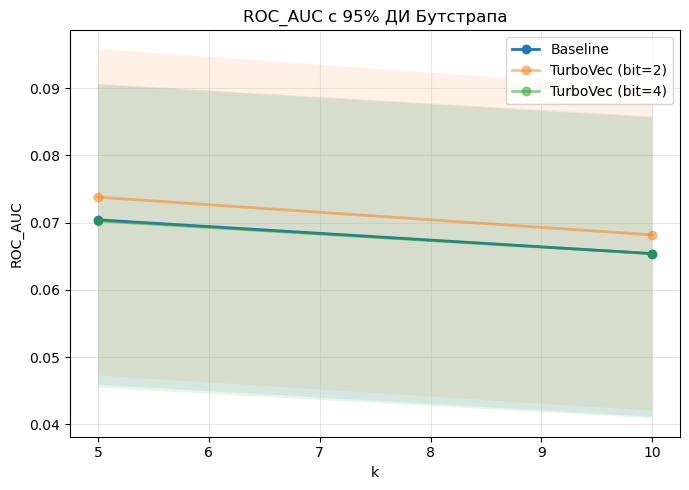

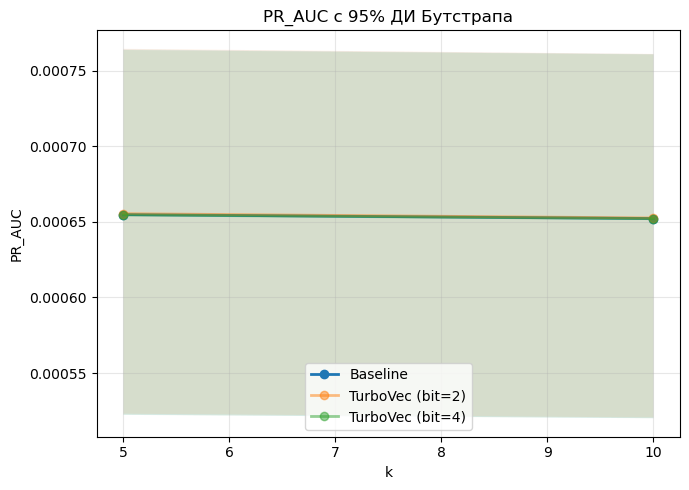

In [83]:
plot_metric_with_ci(ci_roc_raw, "roc_auc")
plt.show()
plot_metric_with_ci(ci_pr_raw, "pr_auc")
plt.show()

In [88]:
def plot_difference(ci_df, metric):
    df = (ci_df[ci_df["metric"] == metric].sort_values(["bit_width", "k"]))
    plt.figure(figsize=(7,4))
    markers = {2: "o",4: "s"}

    for bit in sorted(df["bit_width"].unique()):
        d = df[df["bit_width"] == bit]

        yerr = np.vstack([
            d["diff_hat"] - d["diff_ci_low"],
            d["diff_ci_high"] - d["diff_hat"]
        ])

        plt.errorbar(
            d["k"],
            d["diff_hat"],
            yerr=yerr,
            marker=markers.get(bit, "o"),
            capsize=5,
            linewidth=2,
            label=f"bit={bit}"
        )

    plt.axhline(
        0,
        color="black",
        linestyle="--"
    )

    plt.xlabel("k")
    plt.ylabel("TurboVec − Baseline")
    plt.title(f"Разница в {metric.upper()} (95% ДИ Бутстрап)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

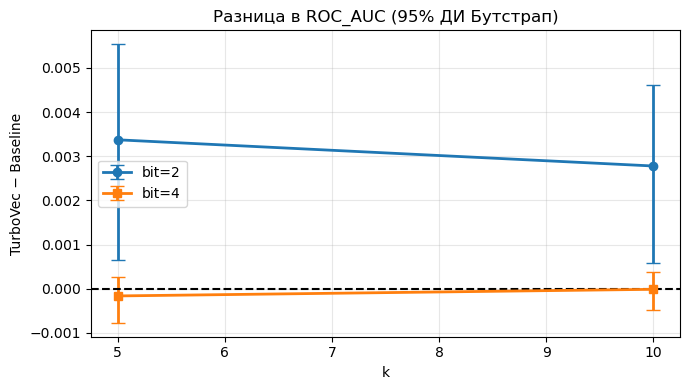

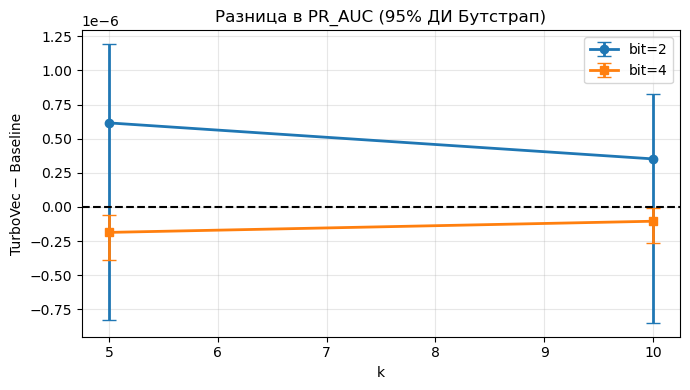

In [89]:
plot_difference(ci_roc_raw, "roc_auc")
plt.show()
plot_difference(ci_pr_raw, "pr_auc")
plt.show()

### Вывод
Turbovec не уступает baseline по метрикам. Bit width = 2 даже лучше, чем сжатие до 4 битов.

## 6. Анализ по времени

Разбиваем `test_id` на временные окна (`time_bin`) и смотрим динамику: растёт ли число
ошибок/падает ли ROC-AUC ближе к концу теста.

In [31]:
N_BINS = 20  # чем меньше аномалий - тем меньше N_BINS

def compute_time_bins(df, n_bins=N_BINS, group_cols=('variant', 'k')):
    df = df.copy()
    df['time_bin'] = pd.cut(df['test_id'], bins=n_bins, labels=False)
    rows = []
    for keys, g in df.groupby(list(group_cols) + ['time_bin']):
        *group_keys, time_bin = keys if isinstance(keys, tuple) else (keys,)
        y = g['true_label'].values
        s = g['anomaly_score'].values
        n_anom = int(y.sum())
        row = dict(zip(group_cols, group_keys))
        row['time_bin'] = time_bin
        row['test_id_min'] = g['test_id'].min()
        row['test_id_max'] = g['test_id'].max()
        row['n'] = len(g)
        row['n_anomalies'] = n_anom
        row['anomaly_rate'] = n_anom / len(g) if len(g) else np.nan
        row['time_ms_median'] = g['time_ms'].median()
        row['time_ms_p95'] = np.percentile(g['time_ms'], 95)
        if len(np.unique(y)) < 2:
            row['roc_auc'] = np.nan
            row['pr_auc'] = np.nan
        else:
            auc_pos = roc_auc_score(y, s)
            auc_neg = roc_auc_score(y, -s)
            if auc_pos >= auc_neg:
                row['roc_auc'] = auc_pos
                row['pr_auc'] = average_precision_score(y, s)
            else:
                row['roc_auc'] = auc_neg
                row['pr_auc'] = average_precision_score(y, -s)
        rows.append(row)
    return pd.DataFrame(rows).sort_values(list(group_cols) + ['time_bin']).reset_index(drop=True)

In [32]:
time_bins_raw = compute_time_bins(df_raw)
time_bins_raw.head()

,variant,k,time_bin,test_id_min,test_id_max,n,n_anomalies,anomaly_rate,time_ms_median,time_ms_p95,roc_auc,pr_auc
0,baseline,5,0,1,4241,4241,7,0.001651,2.231598,4.468679,0.912106,0.020593
1,baseline,5,1,4242,8481,4240,1,0.000236,3.422141,4.742694,0.980892,0.012195
2,baseline,5,2,8482,12721,4240,3,0.000708,2.133965,2.893972,0.979624,0.021851
3,baseline,5,3,12722,16962,4241,7,0.001651,2.103090,2.774477,0.946623,0.023485
4,baseline,5,4,16963,21202,4240,6,0.001415,2.137303,2.873743,0.816801,0.009320


In [33]:
time_bins_norm = compute_time_bins(df_norm)
time_bins_norm

,variant,k,time_bin,test_id_min,test_id_max,n,n_anomalies,anomaly_rate,time_ms_median,time_ms_p95,roc_auc,pr_auc
0,baseline,5,0,1,4241,4241,7,0.001651,3.931761,5.201578,0.841386,0.064904
1,baseline,5,1,4242,8481,4240,1,0.000236,3.772259,5.040133,0.545883,0.000519
2,baseline,5,2,8482,12721,4240,3,0.000708,3.802896,5.074751,0.652978,0.001301
3,baseline,5,3,12722,16962,4241,7,0.001651,3.724575,5.020618,0.774614,0.006697
4,baseline,5,4,16963,21202,4240,6,0.001415,3.710389,5.023003,0.866163,0.253623
...,...,...,...,...,...,...,...,...,...,...,...,...
115,turbovec_bw4,10,15,63606,67845,4240,1,0.000236,0.854254,1.494229,0.541165,0.000514
116,turbovec_bw4,10,16,67846,72086,4241,1,0.000236,0.862360,1.497984,0.867925,0.001783
117,turbovec_bw4,10,17,72087,76326,4240,5,0.001179,0.814199,1.473188,0.648406,0.006134
118,turbovec_bw4,10,18,76327,80566,4240,4,0.000943,0.839949,1.493645,0.693874,0.001897


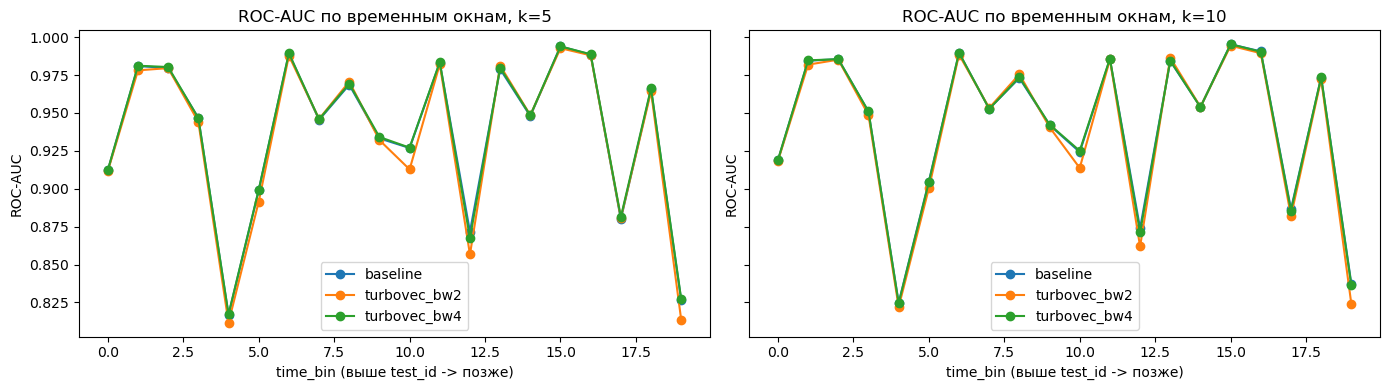

In [87]:
# Динамика ROC-AUC по времени (test_id) — "чаще ли ошибается со временем"
fig, axes = plt.subplots(1, len(RUN_ID), figsize=(7 * len(RUN_ID), 4), sharey=True)
for ax, k in zip(np.atleast_1d(axes), RUN_ID):
    sub = time_bins_raw[time_bins_raw['k'] == k]
    for variant, g in sub.groupby('variant'):
        ax.plot(g['time_bin'], g['roc_auc'], marker='o', label=variant)
    ax.set_title(f'ROC-AUC по временным окнам, k={k}')
    ax.set_xlabel('time_bin (выше test_id -> позже)')
    ax.set_ylabel('ROC-AUC')
    ax.legend()
plt.tight_layout()
plt.show()